### Calculating the board

In [88]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [89]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [90]:
test_image_path = "../code/captured_images/image_96.jpg"

In [91]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_96.jpg: 480x640 1 Board, 1 White_start, 36.1ms
Speed: 1.8ms preprocess, 36.1ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


In [92]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Board', 1: 'White_start'}
obb: None
orig_img: array([[[ 16,  15,  17],
        [ 15,  14,  16],
        [ 14,  13,  15],
        ...,
        [  5,  45,  98],
        [  7,  46, 101],
        [ 13,  52, 107]],

       [[ 15,  14,  16],
        [ 14,  13,  15],
        [ 14,  13,  15],
        ...,
        [  2,  42,  95],
        [  1,  39,  93],
        [  3,  43,  96]],

       [[ 14,  14,  14],
        [ 14,  14,  14],
        [ 13,  13,  13],
        ...,
        [  0,  36,  88],
        [  0,  35,  87],
        [  0,  39,  91]],

       ...,

       [[ 69,  84,  87],
        [ 67,  84,  87],
        [ 69,  84,  87],
        ...,
        [140, 164, 186],
        [140, 164, 186],
        [141, 165, 187]],

       [[ 69,  82,  84],
        [ 67,  82,  84],
        [ 69,  82,  84],
        ...,
        [14

In [93]:
def harris_corners(img, max_corners=4):

    """
    For finding the corners of the board for homography.
    Uses harris corner detector and then uses sort_corners
    before returning it as numpy array.
    Defaults to returning 4 corners.

    """


    # Harris response
    harris = cv2.cornerHarris(img, 15, 15, 0.04)
    harris = cv2.dilate(harris, None)

    # Normalize to 0–255 so goodFeaturesToTrack can use it
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX)
    harris_norm = np.uint8(harris_norm)

    corners = cv2.goodFeaturesToTrack(
        harris_norm,
        maxCorners=max_corners,
        qualityLevel=0.01,
        minDistance=60
    )

    corners = np.array([tuple(pt.ravel()) for pt in corners])
    corners = sort_corners(corners)


    if corners is None:
        Exception("No corners")

    return corners

def plot_corners(img, corners, radius=4, color=(0,0,255), thickness=-1):
    """
    Debugging function

    img: input image (grayscale or BGR)
    corners: list of (x, y) tuples
    """
    # Convert grayscale to BGR so colored dots show up
    if len(img.shape) == 2:
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = img.copy()

    for (x, y) in corners:
        cv2.circle(img_color, (int(x), int(y)), radius, color, thickness)

    return img_color

import numpy as np

def sort_corners(corners):
    """
    Sorts the corners from harris detector
    corners: list or array of 4 (x, y) points
    returns: array of points ordered as:
             top-left, top-right, bottom-right, bottom-left
    """

    pts = np.array(corners, dtype=np.float32)

    # Step 1: sort by y (top to bottom)
    pts = pts[np.argsort(pts[:,1])]

    # First two are top, last two are bottom
    top = pts[:2]
    bottom = pts[2:]

    # Step 2: sort left-to-right within each row
    top = top[np.argsort(top[:,0])]
    bottom = bottom[np.argsort(bottom[:,0])]

    # Order: TL, TR, BR, BL
    ordered = np.array([bottom[0],bottom[1], top[1], top[0]], dtype=np.float32)
    return ordered

In [94]:
result[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1.], device='cuda:0')
conf: tensor([0.9805, 0.9762], device='cuda:0')
data: tensor([[105.9093,  47.1252, 519.3182, 327.5666,   0.9805,   0.0000],
        [375.1118, 154.2742, 539.3461, 342.8003,   0.9762,   1.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (480, 640)
shape: torch.Size([2, 6])
xywh: tensor([[312.6138, 187.3459, 413.4089, 280.4414],
        [457.2289, 248.5373, 164.2342, 188.5261]], device='cuda:0')
xywhn: tensor([[0.4885, 0.3903, 0.6460, 0.5843],
        [0.7144, 0.5178, 0.2566, 0.3928]], device='cuda:0')
xyxy: tensor([[105.9093,  47.1252, 519.3182, 327.5666],
        [375.1118, 154.2742, 539.3461, 342.8003]], device='cuda:0')
xyxyn: tensor([[0.1655, 0.0982, 0.8114, 0.6824],
        [0.5861, 0.3214, 0.8427, 0.7142]], device='cuda:0')

In [95]:
def find_correct_rotation(homography, result, idx_board,idx_white):
    """
    This is for finding the correct rotation for the board s.t. 
    white is always at the bottom.
    
    
    """

    R90 = np.array([
        [0, -1, 0],
        [1,  0, 0],
        [0,  0, 1]
    ], dtype=np.float32)


    mid_point_x_white,mid_point_y_white = result[0].boxes.xywh[idx_white][0:2].cpu()


    while True:
        white_midpoint = cv2.perspectiveTransform(np.array([[[mid_point_x_white,mid_point_y_white]]]), homography)
        if np.squeeze(white_midpoint)[1] < 0: #White is now on the top. We need to rotate 180 degrees and return.
            return R90 @ R90    #This is a clunky way to do this, but it works.
        else:
            homography = R90 @ homography


    
    


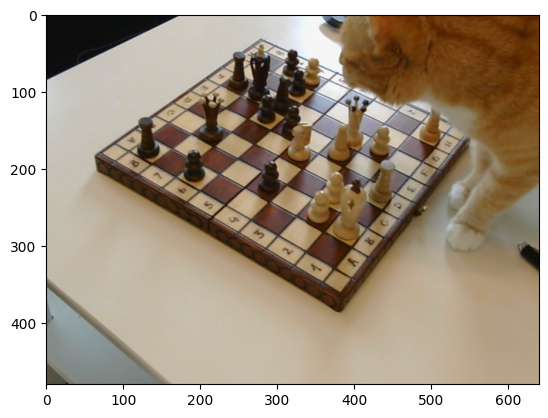

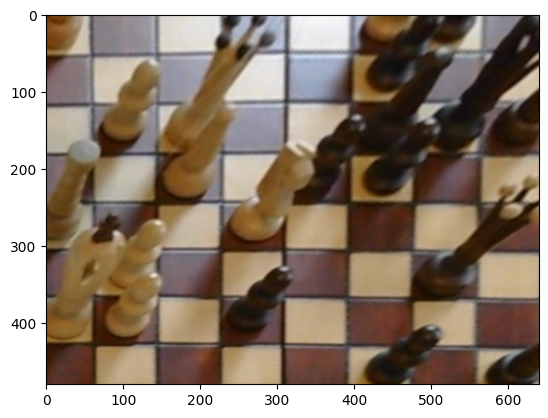

In [96]:
def calculate_homography(result):
    """
        Calculate and return the homography for BEV
        based on the board mask. Takes in a 
        results object from a YOLO model.
        The corners of a square in an image is points
        that are closest to the edges.
    """
    #This section of the code is to figure out which masks is for which object
    #It assumes only 1 detection for both
    detection_dict = result[0].names
    board_label = [k for k, v in detection_dict.items() if v == "Board"][0]
    white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
    objects_detected = result[0].boxes.cls
    idx_board = (objects_detected == board_label).nonzero(as_tuple=True)[0][0].item()
    idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()

    #Finding the corners of the board
    board_mask = result[0].masks.xy[idx_board].astype(np.int32)






    image = cv2.imread(test_image_path)
    zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


    mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
        [board_mask],
        isClosed=True,
        color=255,
        thickness=1
    )


    corners = harris_corners(mask_boundary)
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h,w = img.shape[:2]
    bev_pts = np.array([
        [0, 0],                        
        [w, 0],              
        [w, h],    
        [0, h]              
    ], dtype=np.float32).reshape(-1,1,2)

    #TODO: Figure out rotations (Need to translate to origin I think), displaying the board + the text 
    H, _ = cv2.findHomography(corners, bev_pts)



    not_full_warp = cv2.warpPerspective(
        img,
        H,
        (w,h)
    )



    h_homo,w_homo = not_full_warp.shape[0:2] 
    padding = 0
    T = np.array([
        [1, 0, -padding/2],
        [0, 1, -padding/2],
        [0, 0, 1]
    ], dtype=np.float32)

    T_origin = np.array([
        [1, 0, -w_homo/2],
        [0, 1, -h_homo/2],
        [0, 0, 1]
    ], dtype=np.float32)
    
    T_from_origin = np.array([
        [1, 0, w_homo/2],
        [0, 1, h_homo/2],
        [0, 0, 1]
    ], dtype=np.float32)
    

    rotation = find_correct_rotation(H,result,idx_board,idx_white)



    full_warp = cv2.warpPerspective(
        img,
        T_from_origin @ rotation  @ T_origin @ T @ H,
        (w+padding,h+padding)
    )


    plt.imshow(img)
    plt.show()

    plt.imshow(full_warp)
    plt.show()




calculate_homography(result)


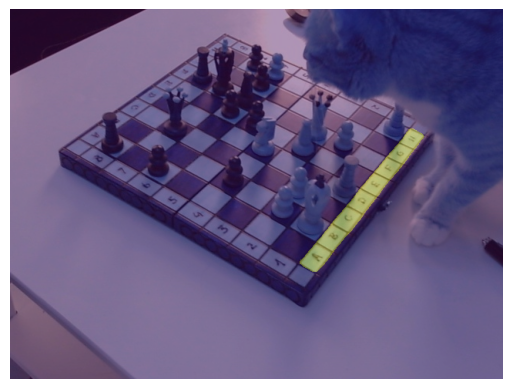

In [97]:

img = result[0].orig_img
mask = result[0].masks.data[1].cpu().numpy()

plt.imshow(img)
plt.imshow(mask, alpha=0.4)  # overlay
plt.axis("off")
plt.show()
